# Модуль A

## Пункт 1.1

### Загрузка библиотек

In [90]:
import pandas as pd
import numpy as np
import requests
import gpxpy
import os
import matplotlib.pyplot as plt
import osmnx as ox
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm import tqdm
import psycopg2
from psycopg2.extras import execute_values
from typing import List, Tuple
from PIL import Image
import io
from geopy.distance import geodesic
from shapely.geometry import Point
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta, datetime, time
import random

tqdm.pandas()

### Загрузка данных в систему

In [6]:
# загрузка данных
def download_file(url):
    local_filename = url.split('/')[-1]
    r = requests.get(url)
    f = open(local_filename, 'wb')
    for chunk in r.iter_content(chunk_size=512 * 1024): 
        if chunk: 
            f.write(chunk)
    f.close()

### Преобразование данных в pandas DataFrame

In [10]:
# функция для получения всех ссылок на файлы
def list_files(dir):
    r = []
    for root, dirs, files in os.walk(dir):
        for name in files:
            r.append(os.path.join(root, name))
    return r

In [11]:
base_dir = "workout-routes"
file_paths = list_files(base_dir)[:3]

In [12]:
#парсинг исходных файлов
Track_ids = [] # идентификатор трека
DateTime = [] # дата и время
Lat = [] # широта точки
Lng = [] # долгота точки
Alt = [] # высота над уровнем моря

for track_id, file_path in enumerate(file_paths):
    gpx_file = open(file_path, "r")
    gpx = gpxpy.parse(gpx_file)
    for track in gpx.tracks:
        for segment in track.segments:
            points = segment.points
            N = len(points)
            for i in range(N):
                point = points[i]
                datetime = point.time
                lat = point.latitude
                lng = point.longitude
                alt = point.elevation
                Track_ids.append(track_id + 1)
                DateTime.append(datetime)
                Lat.append(lat)
                Lng.append(lng)
                Alt.append(alt)

In [13]:
#формирование датафрейма
data = pd.DataFrame({
    "Track_id": Track_ids,
    "DateTime": DateTime,
    "Latitude": Lat,
    "Longitude": Lng,
    "Altitude": Alt 
})

data

,Track_id,DateTime,Latitude,Longitude,Altitude
0,1,2022-03-22 17:47:32+00:00,28.526319,77.205764,233.448227
1,1,2022-03-22 17:47:33+00:00,28.526304,77.205761,233.366989
2,1,2022-03-22 17:47:34+00:00,28.526298,77.205760,233.334747
3,1,2022-03-22 17:47:35+00:00,28.526288,77.205757,233.280121
4,1,2022-03-22 17:47:36+00:00,28.526277,77.205755,233.228973
...,...,...,...,...,...
1682,3,2022-07-26 08:38:16+00:00,28.672763,77.249646,211.568863
1683,3,2022-07-26 08:38:17+00:00,28.672766,77.249640,211.554367
1684,3,2022-07-26 08:38:18+00:00,28.672769,77.249634,211.539078
1685,3,2022-07-26 08:38:19+00:00,28.672772,77.249628,211.523132


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3573 entries, 0 to 3572
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype                        
---  ------     --------------  -----                        
 0   Track_id   3573 non-null   int64                        
 1   DateTime   3573 non-null   datetime64[ns, SimpleTZ('Z')]
 2   Latitude   3573 non-null   float64                      
 3   Longitude  3573 non-null   float64                      
 4   Altitude   3573 non-null   float64                      
dtypes: datetime64[ns, SimpleTZ('Z')](1), float64(3), int64(1)
memory usage: 139.7 KB


In [10]:
data.describe()

,Track_id,Latitude,Longitude,Altitude
count,3573.000000,3573.000000,3573.000000,3573.0
mean,2.305626,28.567727,77.206106,0.0
std,0.912194,0.034368,0.010725,0.0
min,1.000000,28.519128,77.181235,0.0
25%,1.000000,28.532915,77.199891,0.0
50%,3.000000,28.568423,77.206428,0.0
75%,3.000000,28.594745,77.210435,0.0
max,3.000000,28.635633,77.234587,0.0


### Получение топографических карт с треками маршрутов

In [7]:
import osmnx as ox
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def visualize_topo_map(points, center_lat, center_lng, radius=1000, filename="map.png"):
    try:
        # получение данных по точке
        G = ox.graph_from_point((center_lat, center_lng), dist=radius, network_type="all", simplify=True)
        
        fig, ax = ox.plot_graph(G, show=False, close=False, 
                              edge_color="gray", node_size=0, 
                              bgcolor="white", figsize=(10, 8))
        # водоёмы (синий)
        try:
            water = ox.features_from_point((center_lat, center_lng), 
                                         tags={"natural": "water"}, 
                                         dist=radius)
            if not water.empty:
                water.plot(ax=ax, color="blue", alpha=0.5)
        except:
            pass
        # здания (оранжевый)
        try:
            buildings = ox.features_from_point((center_lat, center_lng), 
                                              tags={"building": True}, 
                                              dist=radius)
            if not buildings.empty:
                buildings.plot(ax=ax, color="orange", alpha=0.7)
        except:
            pass
        # зелёные зоны (зелёный)
        try:
            green = ox.features_from_point((center_lat, center_lng), 
                                        tags={"landuse": "grass", "natural": "wood"}, 
                                        dist=radius)
            if not green.empty:
                green.plot(ax=ax, color="green", alpha=0.3)
        except:
            pass
        # трек маршрута
        lngs, lats = zip(*points)
        ax.plot(lngs, lats, color="red", linewidth=3)


        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()
        return filename

    except Exception as e:
        print(e)
        return filename

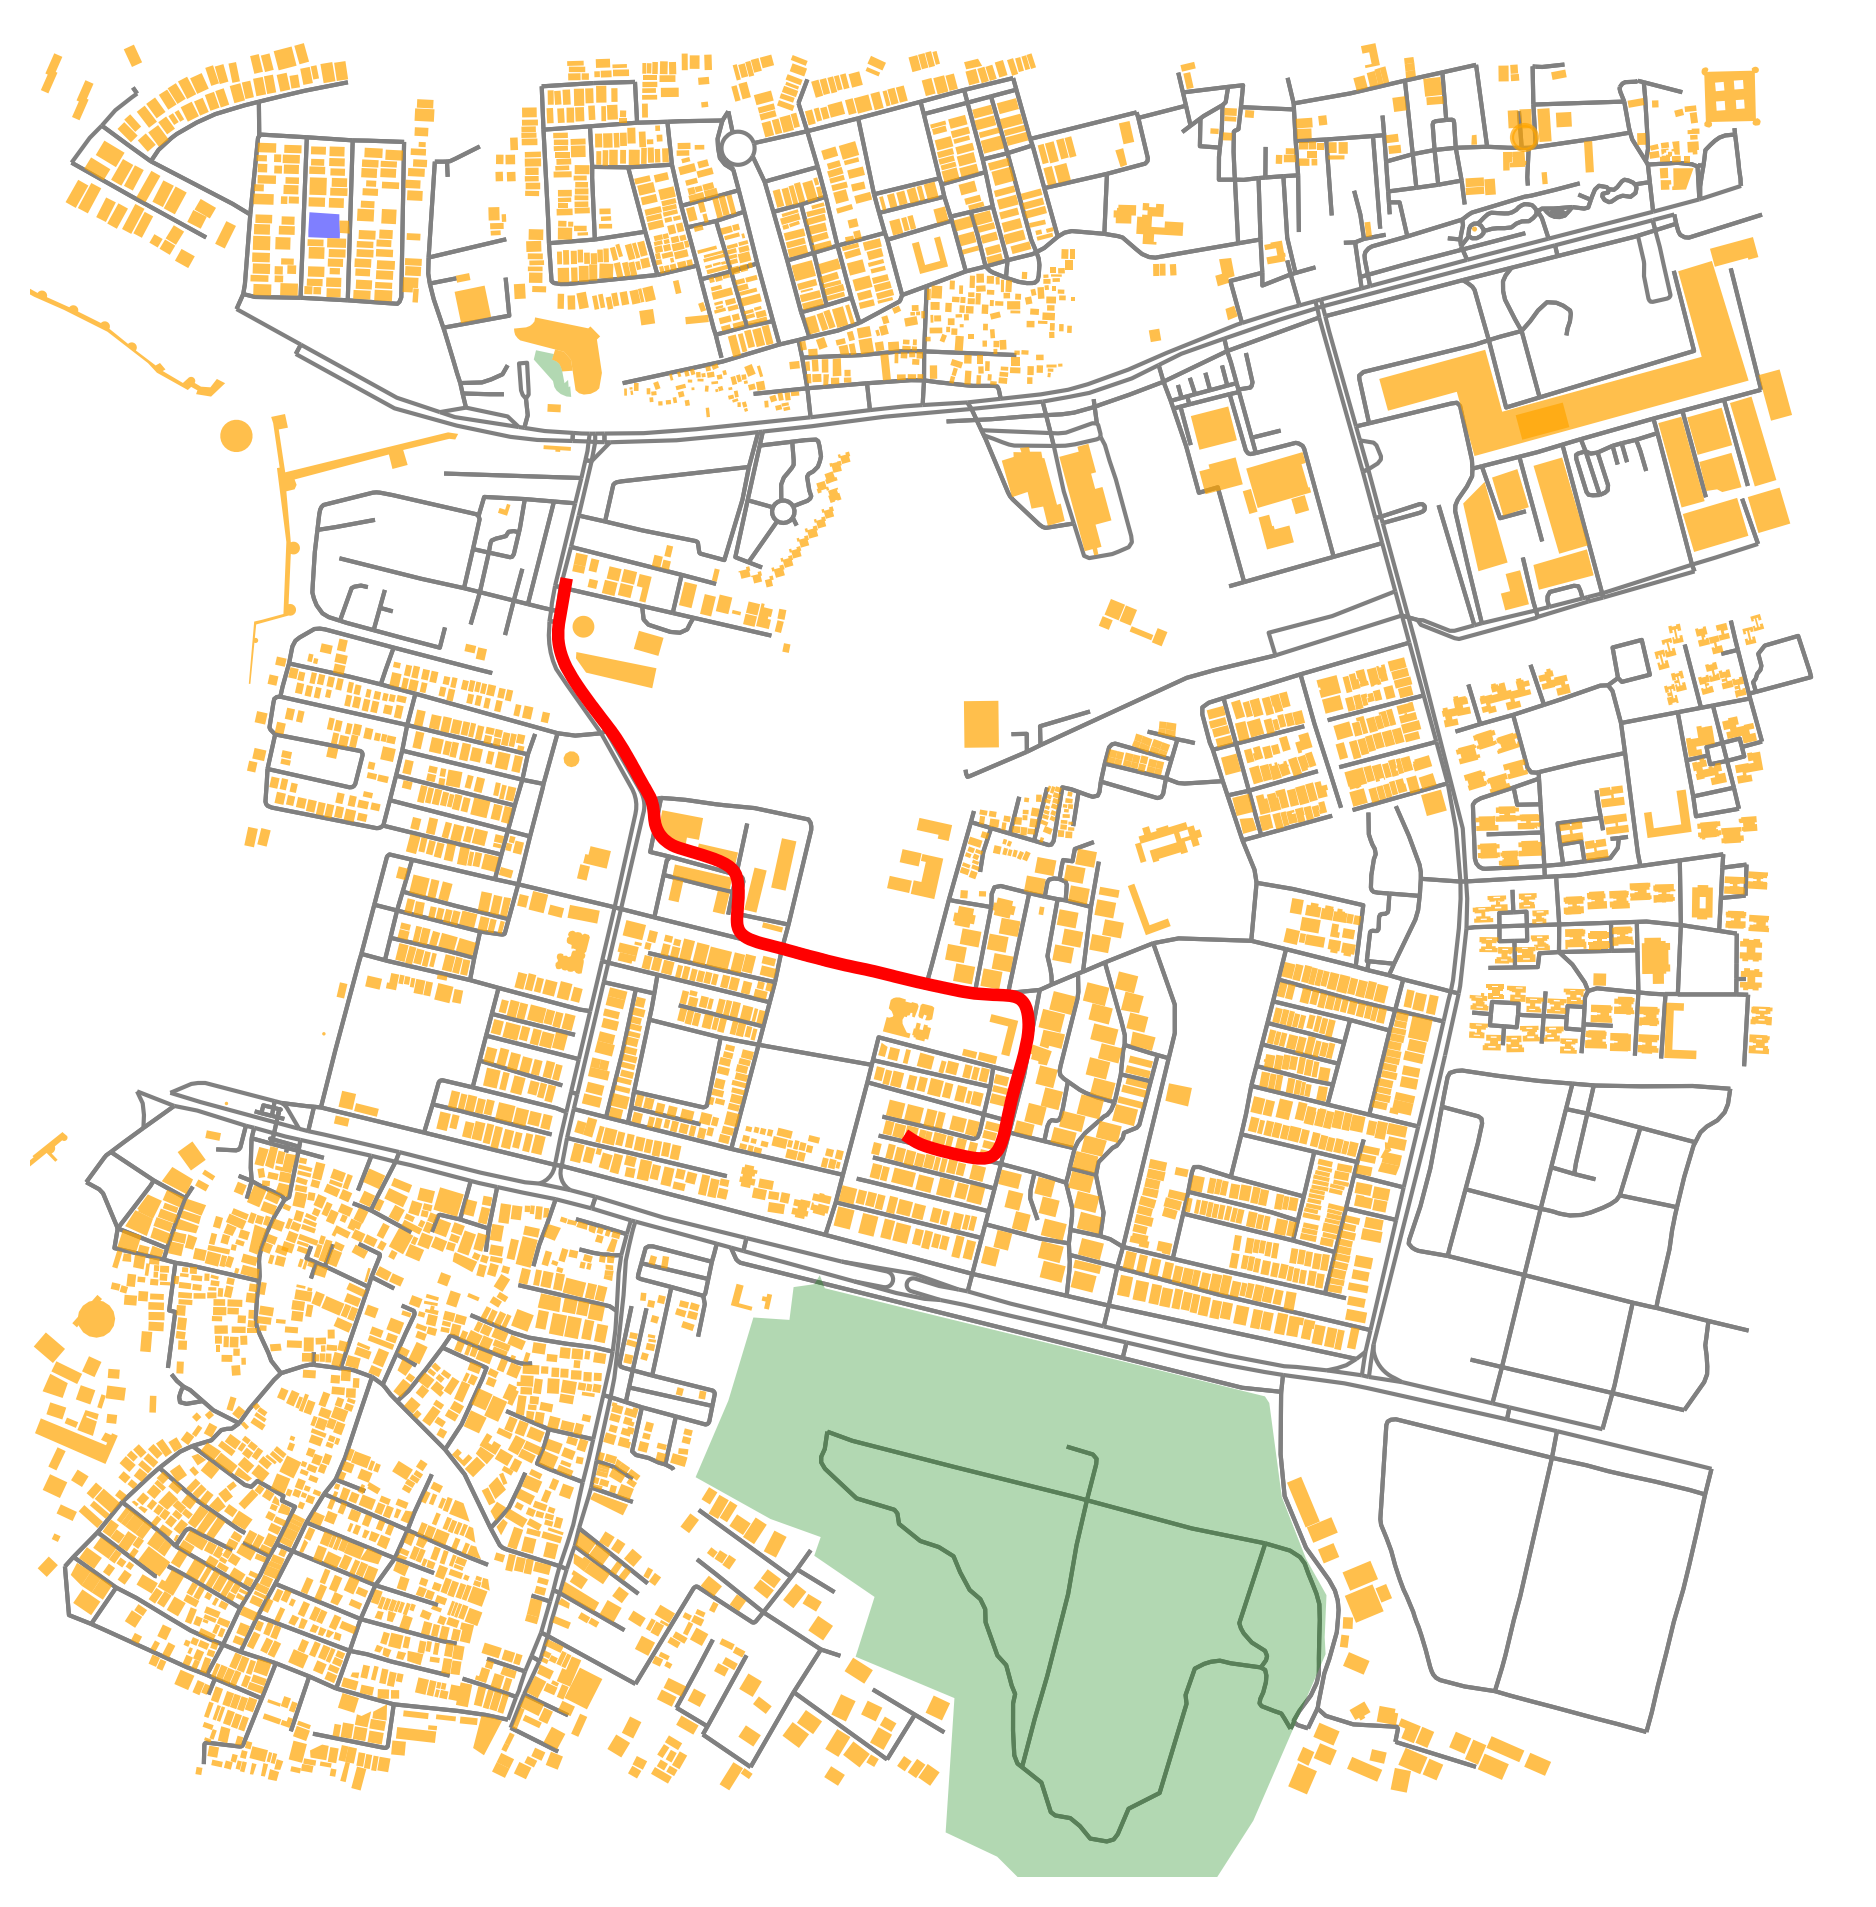

In [19]:
#карта для первого трека
image = Image.open("maps/1.png")
display(image)

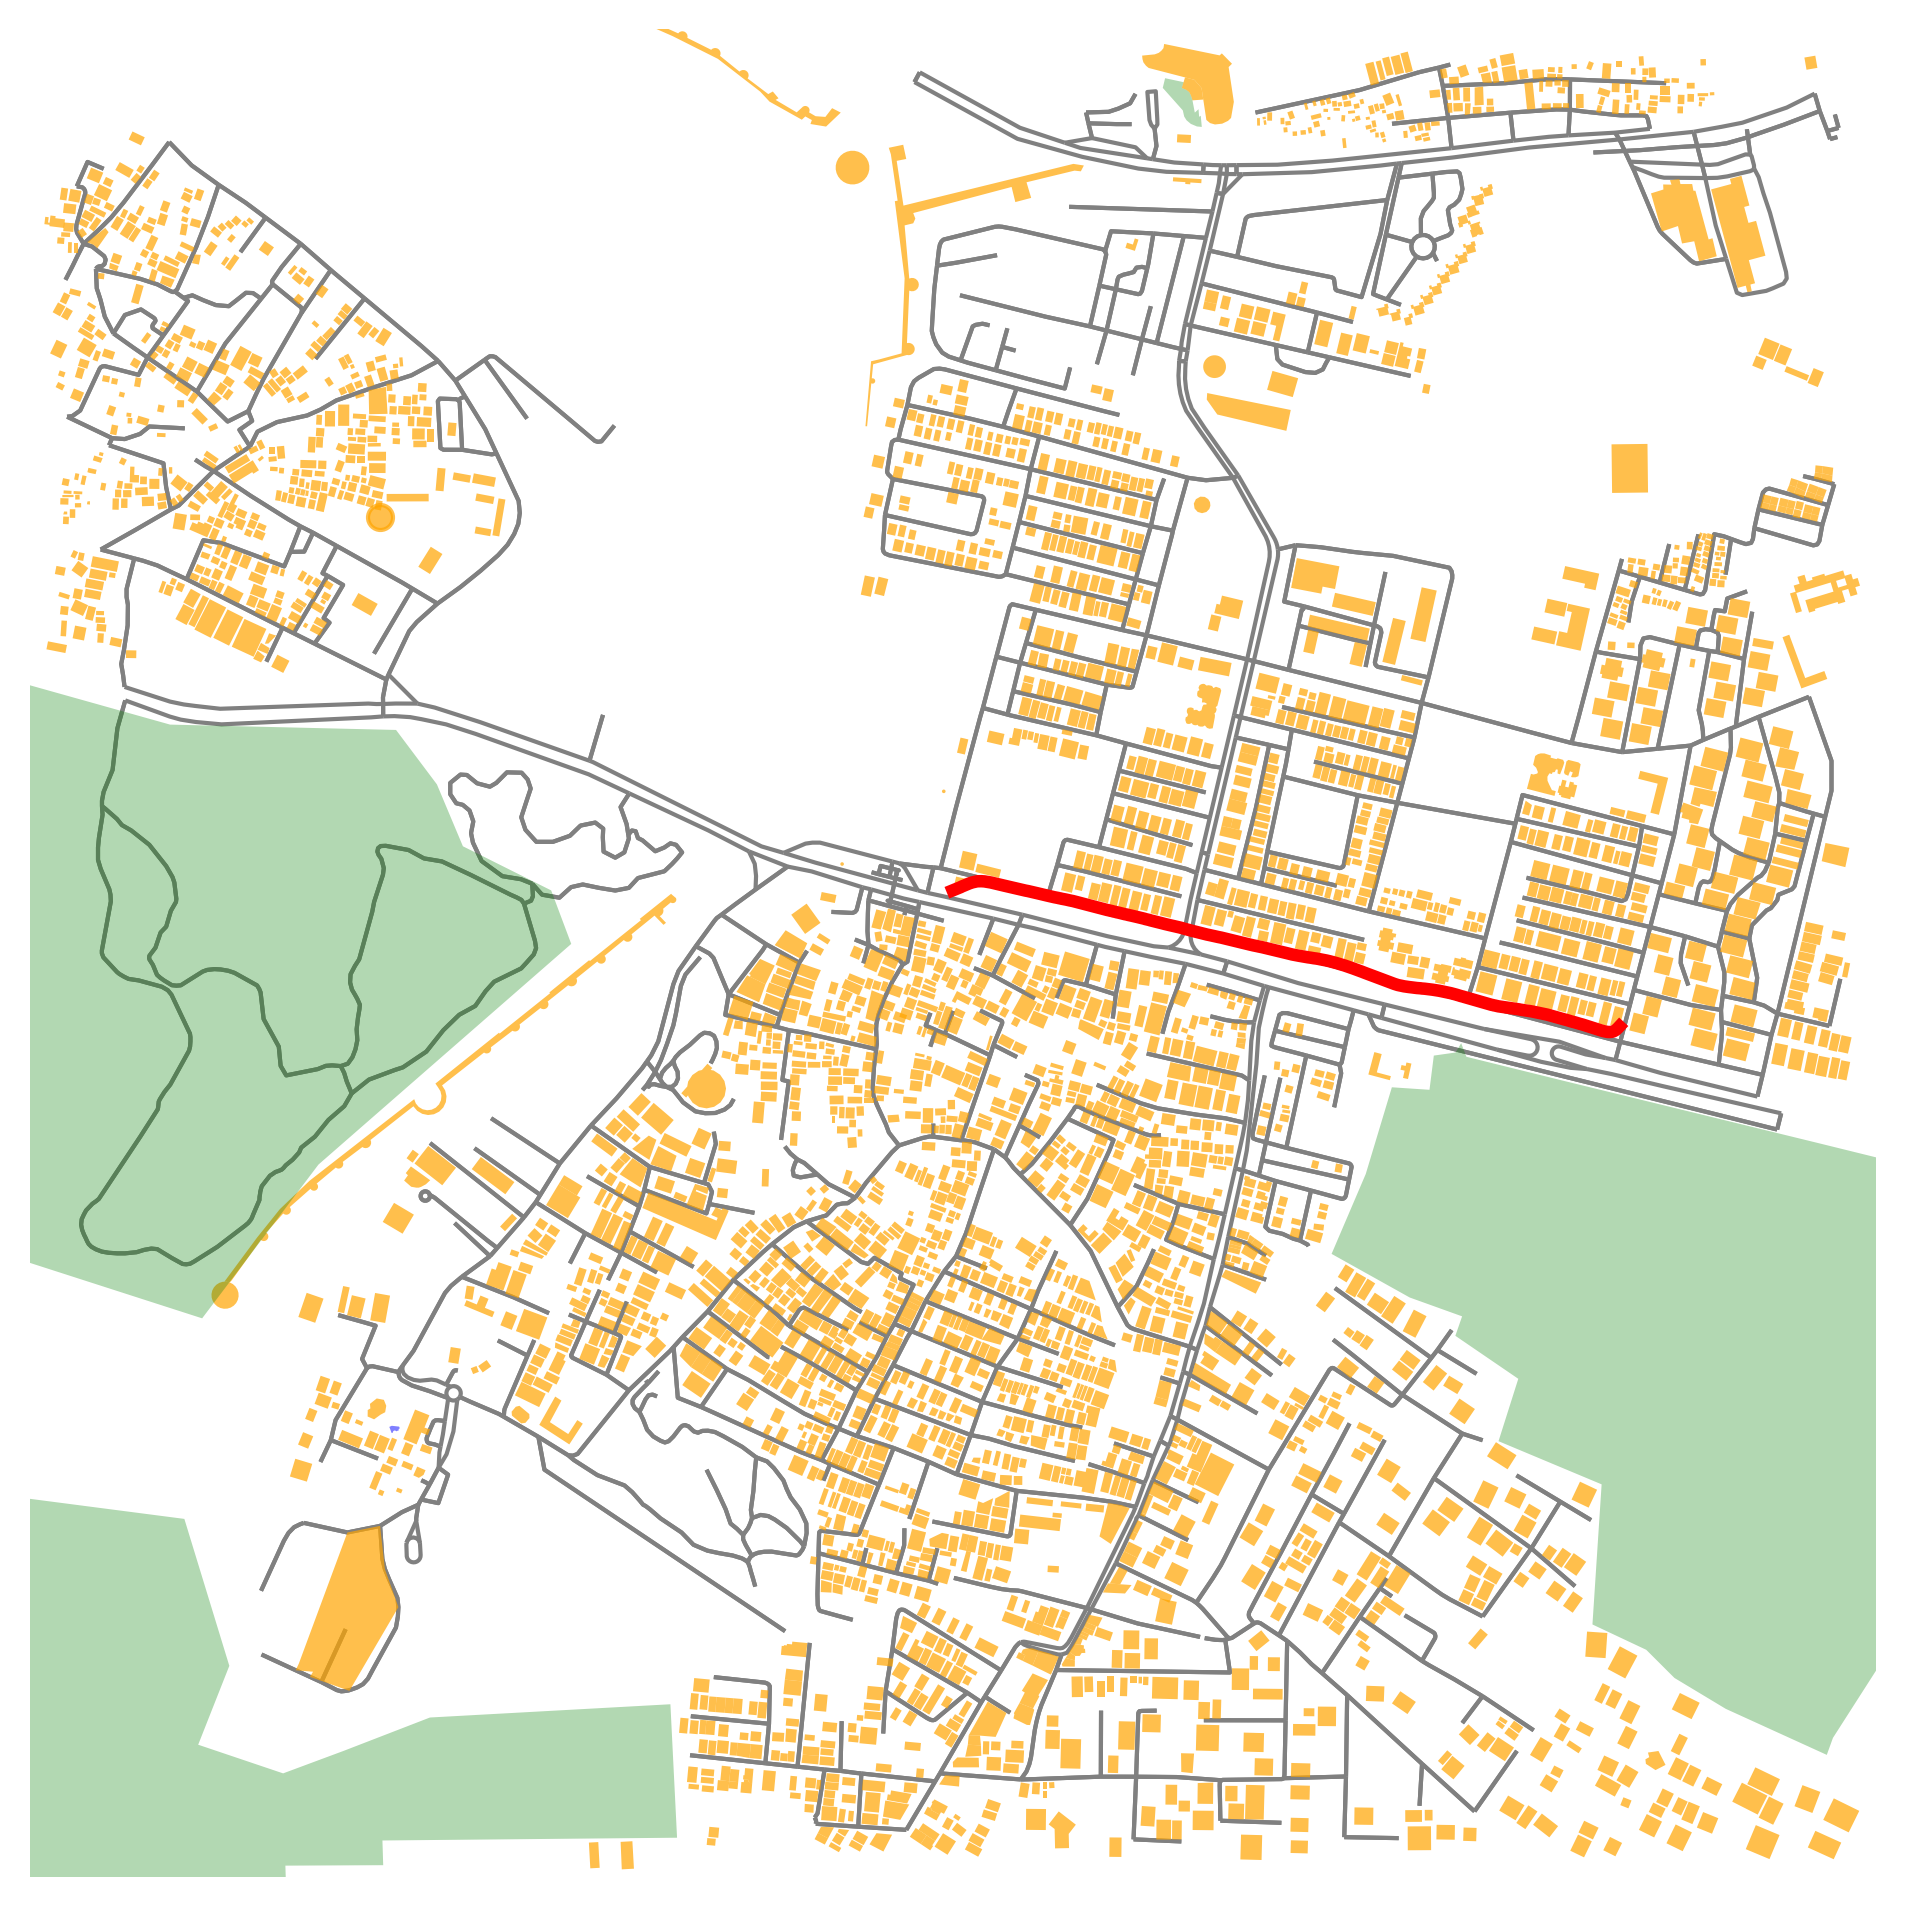

In [20]:
image = Image.open("maps/2.png")
display(image)

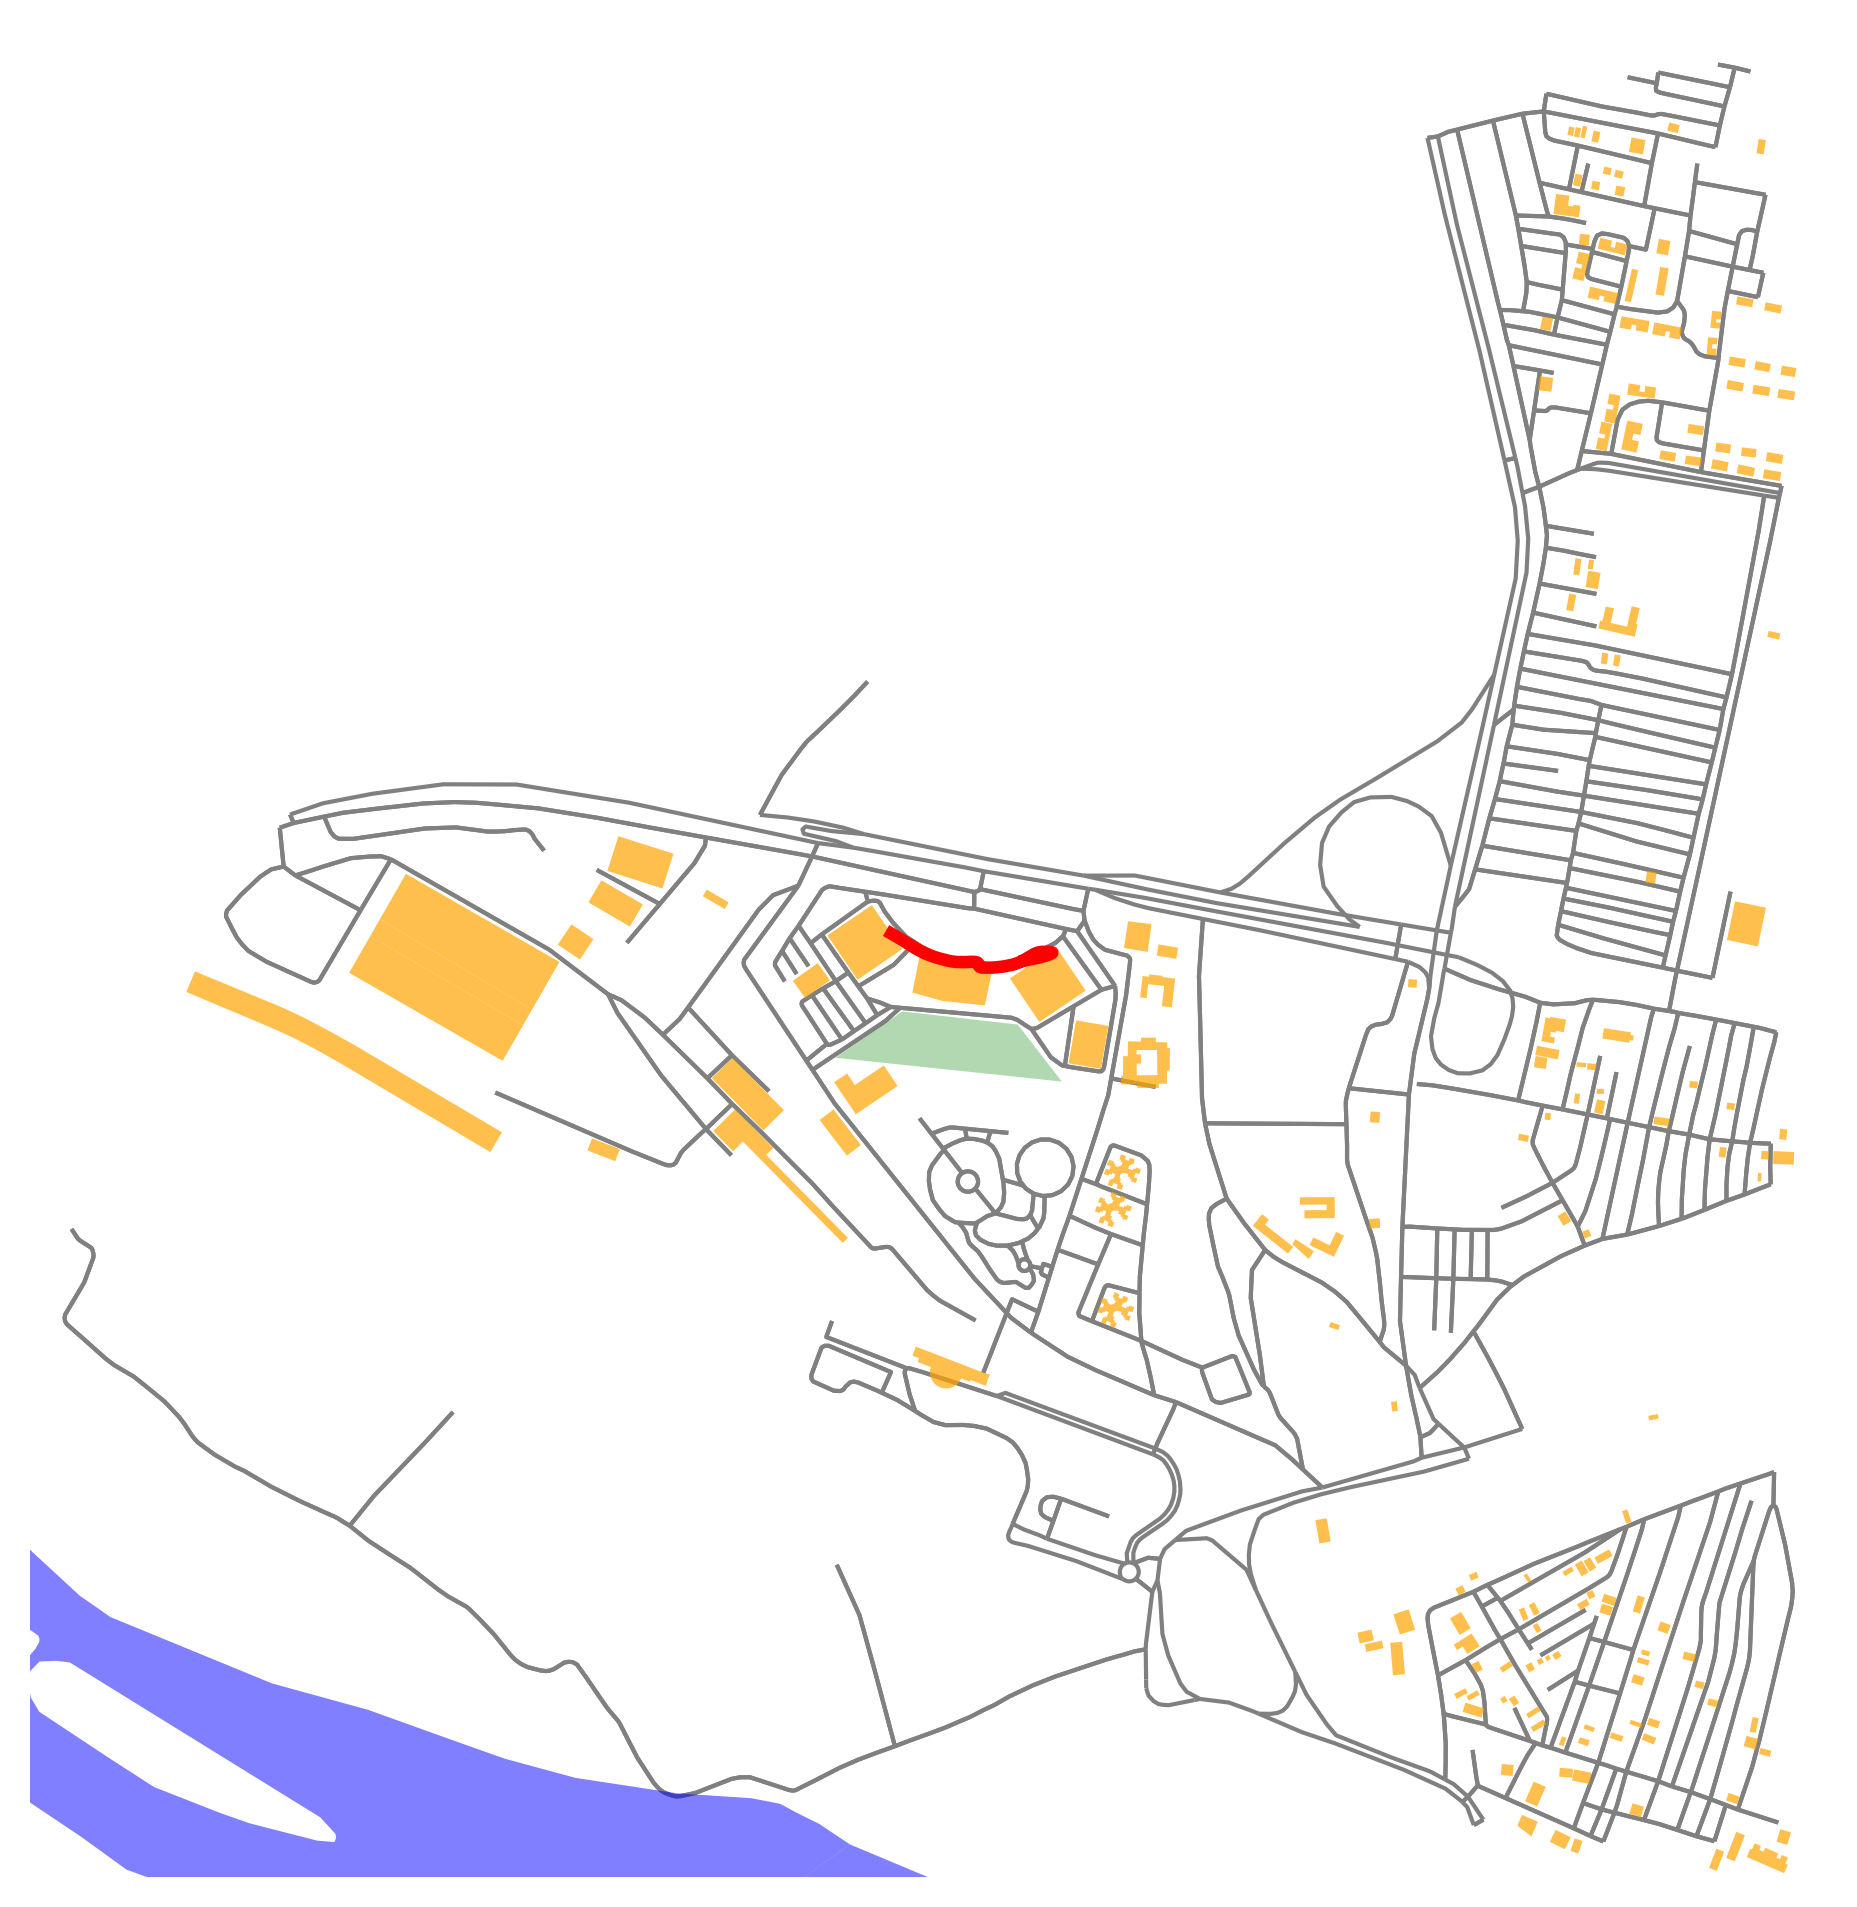

In [21]:
image = Image.open("maps/3.png")
display(image)

In [14]:
# загрузка карт в папку maps
base_dir = "maps"

for track_id, file_path in tqdm(enumerate(file_paths)):
    gpx_file = open(file_path, "r")
    gpx = gpxpy.parse(gpx_file)
    Lat = []
    Lng = []
    for track in gpx.tracks:
        for segment in track.segments:
            points = segment.points
            N = len(points)
            for i in range(N):
                point = points[i]
                lat = point.latitude
                lng = point.longitude
                Lat.append(lat)
                Lng.append(lng)
    
    points=tuple(zip(Lng, Lat))
    center_lat = np.mean(Lat)
    center_lng = np.mean(lng)
    filename = os.path.join(base_dir, str(track_id + 1) + ".png")

    topo_map = visualize_topo_map(points, center_lat, center_lng, filename=filename)

3it [00:33, 11.28s/it]


### Загрузка в базу данных

In [22]:
def get_conn(dbname, user, password, host, port):
    return psycopg2.connect(dbname=dbname, user=user, password=password, host=host, port=port)

In [23]:
dbname = "Routes_tracks" 
user = "postgres" 
password = "86754231qaZ" 
host = "localhost" 
port = "5434" 

conn = get_conn(dbname, user, password, host, port)

In [ ]:
#cоздание таблицы с картами
query = """CREATE TABLE IF NOT EXISTS Track_Maps (
    id SERIAL PRIMARY KEY,
    track_id INTEGER NOT NULL UNIQUE,
    image BYTEA NOT NULL
);"""

try:
    cur = conn.cursor()
    cur.execute(query)
    conn.commit()

except Exception as e:
    print("Ошибка:", e)
    conn.close()


In [ ]:
#cоздание таблицы с точками
query = """CREATE TABLE IF NOT EXISTS Track_Points (
    id SERIAL PRIMARY KEY,
    track_id INTEGER NOT NULL REFERENCES Track_Maps (track_id),
    \"DateTime\" TIMESTAMP NOT NULL,
    Latitude NUMERIC NOT NULL,
    Longitude NUMERIC NOT NULL,
    Altitude NUMERIC NOT NULL
);"""

try:
    cur = conn.cursor()
    cur.execute(query)
    conn.commit()

except Exception as e:
    print("Ошибка:", e)
    conn.close()


In [ ]:
# добавление данных о точках в бд

query = """INSERT INTO Track_Points (track_id, \"DateTime\", Latitude, Longitude, Altitude)
        VALUES %s"""

try:
    cur = conn.cursor()
    execute_values(cur, query, data.values.tolist())
    conn.commit()

except Exception as e:
    print("Ошибка:", e)
    conn.close()

In [ ]:
# добавление данных в таблицу бд с картой
def insert_data_with_image(query, data, image_path):
    try:
        cur = conn.cursor()
        with open(image_path, 'rb') as file:
            binary_data = file.read()
        cur.execute(query, (data, binary_data,))
        conn.commit()

    except Exception as e:
        print("Ошибка:", e)
        conn.close()

In [ ]:
# добавление данных в таблицу бд с картой
query = """INSERT INTO Track_Maps (track_id, image)
        VALUES (%s, %s)"""

for track_id in range(1, 4):
        try:
                image = os.path.join(base_dir, str(track_id) + ".png")
                cur = conn.cursor()
                with open(image, 'rb') as file:
                        binary_data = file.read()
                cur.execute(query, (data, binary_data,))
                conn.commit()
        except:
                print("Ошибка:", e)
                conn.close()

## Пункт 1.2

### Получение окружающей среды для каждой точки трека

In [59]:
# загрузка полученных ранее данных из бд
data = pd.read_sql("SELECT * FROM Track_Points", conn).drop(columns="id")

/var/folders/lq/13c4rlw92f7_q2025mqwt1fm0000gn/T/ipykernel_13453/1317022102.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql("SELECT * FROM Track_Points", conn).drop(columns="id")


In [60]:
data

,track_id,DateTime,latitude,longitude,altitude
0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227
1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989
2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747
3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121
4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973
...,...,...,...,...,...
1682,3,2022-07-26 18:38:16,28.672763,77.249646,211.568863
1683,3,2022-07-26 18:38:17,28.672766,77.249640,211.554367
1684,3,2022-07-26 18:38:18,28.672769,77.249634,211.539078
1685,3,2022-07-26 18:38:19,28.672772,77.249628,211.523132


In [ ]:
# функция для получения окружающих точку объектов
def get_track_environment(points, radius=500):
    results = []
    
    for i, (track_id, lng, lat, alt) in tqdm(enumerate(points)):
        point_data = {
            'point_id': i,
            'track_id': track_id,
            'latitude': lat,
            'longitude': lng,
            'altitude': alt,
            'water_dist': -1,
            'building_dist': -1,
            'green_dist': -1,
            "water_area": -1,
            "building_area": -1,
            "green_area": -1
        }
        
        try:
            # справочник объектов
            tags_config = {
                'water': {"natural": "water"},
                'building': {"building": True},
                'green': {"landuse": "grass", "natural": "wood"}
            }
            
            for obj_type, tags in tags_config.items():
                    try:
                        gdf = ox.features_from_point((lat, lng), tags=tags, dist=radius)
                    except:
                        continue
                    
                    if not gdf.empty:
                        # вычисляем расстояние до всех объектов этого типа
                        distances = []
                        areas = []
                        for geom in gdf.geometry:
                            if geom.geom_type == 'Point':
                                obj_point = (geom.y, geom.x)
                                dist = geodesic((lat, lng), obj_point).meters
                                distances.append(dist)
                            elif geom.geom_type in ['Polygon', 'MultiPolygon']:
                                # для полигонов берем расстояние до ближайшей точки границы
                                for x, y in geom.exterior.coords:
                                    obj_point = (y, x)
                                    dist = geodesic((lat, lng), obj_point).meters
                                    distances.append(dist)
                                # площадь полигона
                                area = geom.area * 1e8 # 
                                areas.append(area)
                        
                        # запись данных
                        if distances:
                            point_data[f'{obj_type}_dist'] = min(distances)
                            point_data[f'{obj_type}_area'] = sum(areas)
                
                        
        except Exception as e:
            print(f"Ошибка для точки {i}: {e}")
        
        results.append(point_data)
    
    return pd.DataFrame(results)

In [ ]:
def process_point(point, radius=500):
    track_id, lng, lat, alt = point
    point_data = {
        'track_id': track_id,
        'latitude': lat,
        'longitude': lng,
        'altitude': alt,
        'water_dist': -1,
        'building_dist': -1,
        'green_dist': -1,
        "water_area": -1,
        "building_area": -1,
        "green_area": -1
    }

    try:
        # справочник объектов
        tags_config = {
            'water': {"natural": "water"},
            'building': {"building": True},
            'green': {"landuse": "grass", "natural": "wood"}
        }

        for obj_type, tags in tags_config.items():
            try:
                gdf = ox.features_from_point((lat, lng), tags=tags, dist=radius)
            except Exception as e:
                continue

            if not gdf.empty:
                # вычисляем расстояния до всех объектов этого типа
                distances = []
                areas = []
                for geom in gdf.geometry:
                    if geom.geom_type == 'Point':
                        obj_point = (geom.y, geom.x)
                        dist = geodesic((lat, lng), obj_point).meters
                        distances.append(dist)
                    elif geom.geom_type in ['Polygon', 'MultiPolygon']:
                        # для полигонов берем расстояние до ближайшей точки границы
                        for x, y in geom.exterior.coords:
                            obj_point = (y, x)
                            dist = geodesic((lat, lng), obj_point).meters
                            distances.append(dist)
                        # высчитываем площадь полигона
                        area = geom.area * 1e8 
                        areas.append(area)

                # расстояние до точки
                if distances:
                    point_data[f'{obj_type}_dist'] = min(distances)
                # суммарная площадь объекта
                if areas:
                    point_data[f'{obj_type}_area'] = sum(areas)


    except Exception as e:
        print(f"Ошибка для точки ({lat}, {lng}): {e}")

    return point_data

In [ ]:
# обрабатываю точки в несколько потоков для ускорения работы
def multiprocess_execute(points, radius=500, num_threads=4):
    results = []
    with ThreadPoolExecutor(max_workers=num_threads) as executor:
        futures = [executor.submit(process_point, point, radius) for point in points]

        for i, future in tqdm(enumerate(as_completed(futures)), total=len(points)):
            try:
                result = future.result() 
                results.append(result)
                if (i + 1) % 100 == 0:
                    results_df = pd.DataFrame(results)
                    results_df.to_csv("points_data/results.csv")
            except Exception as e:
                print(f"Ошибка при получении результата из потока: {e}")

    return pd.DataFrame(results)

In [12]:
cols = ["track_id", "longitude", "latitude", "altitude"]

points = data.groupby(cols).count().reset_index()[cols]

points

,track_id,longitude,latitude,altitude
0,1,77.205674,28.525768,235.212418
1,1,77.205674,28.525780,235.187759
2,1,77.205674,28.525792,235.160965
3,1,77.205674,28.525804,235.131699
4,1,77.205674,28.525816,235.099670
...,...,...,...,...
1682,3,77.251454,28.672586,211.812775
1683,3,77.251454,28.672592,211.846344
1684,3,77.251456,28.672588,211.823227
1685,3,77.251456,28.672589,211.832489


In [27]:
points_data = multiprocess_execute(points.values.tolist()[1200:1400], num_threads=8)

100%|██████████| 200/200 [06:34<00:00,  1.97s/it]


In [27]:
points_data = pd.read_csv("points_data/results.csv").drop(columns=["Unnamed: 0"])

points_data

,track_id,latitude,longitude,altitude,water_dist,building_dist,green_dist,water_area,building_area,green_area
0,1.0,28.525757,77.205675,235.234741,532.657822,19.483674,281.893739,9.614001,1246.489823,9.068051
1,1.0,28.525745,77.205675,235.254837,533.823514,20.056254,283.221736,9.614001,1247.962031,9.068051
2,1.0,28.525804,77.205674,235.131699,528.052098,17.872922,276.698006,9.614001,1253.050435,9.068051
3,1.0,28.525768,77.205674,235.212418,531.542690,19.117236,280.681759,9.614001,1245.795961,9.068051
4,1.0,28.525828,77.205675,235.065063,525.776764,17.290614,274.036805,9.614001,1260.986621,9.068051
...,...,...,...,...,...,...,...,...,...,...
995,2.0,28.520317,77.205041,235.920578,-1.000000,7.097671,348.860123,-1.000000,1882.841360,3102.917350
996,2.0,28.520258,77.205314,235.671310,-1.000000,7.834182,323.075677,-1.000000,1914.913525,3102.917350
997,2.0,28.520274,77.205240,235.694000,-1.000000,7.947379,330.037782,-1.000000,1903.137043,3102.917350
998,2.0,28.520251,77.205343,235.666214,-1.000000,8.284022,320.306776,-1.000000,1909.735361,3102.917350


### Получение температуры

In [67]:
def get_temperature(lat, lng, date):
    try:
        base_url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": lat,
            "longitude": lng,
            "start_date": date.strftime("%Y-%m-%d"),  # YYYY-MM-DD
            "end_date": date.strftime("%Y-%m-%d"),    # YYYY-MM-DD
            "hourly": "temperature_2m"
        }

        response = requests.get(base_url, params=params, timeout=10)

        hour = date.hour

        return response.json()["hourly"]["temperature_2m"][hour]
    except:
        return None

In [68]:
temps = []

for lat, lng, date in tqdm(data[["latitude", "longitude", "DateTime"]].values):
    temps.append(get_temperature(lat, lng, date))

data["temp"] = temps

100%|██████████| 1687/1687 [01:32<00:00, 18.18it/s] 


In [70]:
data["temp"] = random.choices(range(10, 30), k=len(data)) # Для примера, не использовать в работе

### Получение названия региона

In [72]:
regions = pd.DataFrame(data["track_id"].unique(), columns=["track_id"])
regions["region"] = regions["track_id"].map({1: "Region 1", 2: "Region 2", 3: "Region 3"})

regions

,track_id,region
0,1,Region 1
1,2,Region 2
2,3,Region 3


In [73]:
# итоговый набор данных
data = data.merge(regions, on="track_id")
data = data.merge(points_data, on=["track_id", "latitude", "longitude", "altitude"])

data

,track_id,DateTime,latitude,longitude,altitude,temp,region,water_dist,building_dist,green_dist,water_area,building_area,green_area
0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227,21,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051
1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989,16,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051
2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747,25,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051
3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121,19,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051
4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973,21,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,2022-03-24 14:15:19,28.520591,77.203003,235.674286,15,Region 2,-1.000000,5.059959,437.808130,-1.000000,1851.158175,7450.647125
996,2,2022-03-24 14:15:20,28.520587,77.202993,235.622757,21,Region 2,-1.000000,5.173381,436.776815,-1.000000,1846.372356,7450.647125
997,2,2022-03-24 14:15:21,28.520584,77.202984,235.570862,23,Region 2,-1.000000,5.390939,435.858069,-1.000000,1850.204349,7450.647125
998,2,2022-03-24 14:15:22,28.520580,77.202974,235.519058,24,Region 2,-1.000000,5.878070,434.827106,-1.000000,1848.577678,7450.647125


Быд собран итоговый набор данных, включая в себя номер трека, координаты, высоту, расстояние до водоемов, построек и полей, а так же площадь найденных объектов, находящихся в пределах 500 метров от точки

### Пункт 1.3

### Добавление всесезонности

In [74]:
for track_id in range(1, 4):
    print(f'Мин дата для трека {track_id}: {data[data["track_id"] == track_id]["DateTime"].min()}')
    print(f'Макс дата для трека {track_id}: {data[data["track_id"] == track_id]["DateTime"].max()}')
    print()

Мин дата для трека 1: 2022-03-23 03:47:32
Макс дата для трека 1: 2022-03-23 04:01:18

Мин дата для трека 2: 2022-03-24 14:12:23
Макс дата для трека 2: 2022-03-24 14:15:23

Мин дата для трека 3: NaT
Макс дата для трека 3: NaT



In [75]:
avg_temps = {
    1: {
        "День": {
            "Зима": -10.5,
            "Весна": 12.2,
            "Лето": 25.8,
            "Осень": 8.9
        },
        "Ночь": {
            "Зима": -15.2,
            "Весна": 5.1,
            "Лето": 18.5,
            "Осень": 3.2
        }
    },
    2: {
        "День": {
            "Зима": -8.0,
            "Весна": 14.5,
            "Лето": 27.1,
            "Осень": 10.5
        },
        "Ночь": {
            "Зима": -12.7,
            "Весна": 7.4,
            "Лето": 20.0,
            "Осень": 4.8
        }
    },
    3: {
        "День": {
            "Зима": -12.3,
            "Весна": 10.8,
            "Лето": 24.6,
            "Осень": 7.1
        },
        "Ночь": {
            "Зима": -17.0,
            "Весна": 3.7,
            "Лето": 17.3,
            "Осень": 1.5
        }
    }
}

In [84]:
track_ids = []
dates = []
hours = []

for track_id in range(1, 4):
    used_dates = data[data["track_id"] == track_id]["DateTime"].unique()
    min_date = date(2022, 1, 1)
    for day in range(365):
        gen_date = min_date + timedelta(days=day)
        if gen_date not in used_dates:
            gen_hour = random.randint(0, 23)
            track_ids.append(track_id)
            dates.append(gen_date)
            hours.append(gen_hour)

In [85]:
temps = []

for track_id, gen_date, gen_hour in zip(track_ids, dates, hours):
    month = gen_date.month
    if month in [12, 1, 2]:
        season = "Зима"
    elif month in [3, 4, 5]:
        season = "Весна"
    elif month in [6, 7, 8]:
        season = "Лето"
    else:
        season = "Осень"
    
    if gen_hour in range(6, 18):
        day_half = "День"
    else:
        day_half = "Ночь"
    
    noise = random.uniform(-2, 2)
    temps.append(round(avg_temps[track_id][day_half][season] + noise, 2))

In [92]:
gen_data = pd.DataFrame({
    "track_id": track_ids,
    "DateTime": [datetime.combine(gen_date, time(gen_hour)) for gen_date, gen_hour in zip(dates, hours)],
    "temp": temps
})

gen_data

,track_id,DateTime,temp
0,1,2022-01-01 11:00:00,-10.50
1,1,2022-01-02 04:00:00,-16.05
2,1,2022-01-03 19:00:00,-15.19
3,1,2022-01-04 02:00:00,-15.81
4,1,2022-01-05 13:00:00,-12.29
...,...,...,...
1090,3,2022-12-27 11:00:00,-12.15
1091,3,2022-12-28 01:00:00,-18.17
1092,3,2022-12-29 20:00:00,-16.86
1093,3,2022-12-30 00:00:00,-17.02


In [93]:
gen_data = gen_data.merge(data.drop(columns=["DateTime", "temp"]), on="track_id")

gen_data

,track_id,DateTime,temp,latitude,longitude,altitude,region,water_dist,building_dist,green_dist,water_area,building_area,green_area
0,1,2022-01-01 11:00:00,-10.50,28.526319,77.205764,233.448227,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051
1,1,2022-01-01 11:00:00,-10.50,28.526304,77.205761,233.366989,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051
2,1,2022-01-01 11:00:00,-10.50,28.526298,77.205760,233.334747,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051
3,1,2022-01-01 11:00:00,-10.50,28.526288,77.205757,233.280121,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051
4,1,2022-01-01 11:00:00,-10.50,28.526277,77.205755,233.228973,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051
...,...,...,...,...,...,...,...,...,...,...,...,...,...
364995,2,2022-12-31 21:00:00,-14.45,28.520591,77.203003,235.674286,Region 2,-1.000000,5.059959,437.808130,-1.000000,1851.158175,7450.647125
364996,2,2022-12-31 21:00:00,-14.45,28.520587,77.202993,235.622757,Region 2,-1.000000,5.173381,436.776815,-1.000000,1846.372356,7450.647125
364997,2,2022-12-31 21:00:00,-14.45,28.520584,77.202984,235.570862,Region 2,-1.000000,5.390939,435.858069,-1.000000,1850.204349,7450.647125
364998,2,2022-12-31 21:00:00,-14.45,28.520580,77.202974,235.519058,Region 2,-1.000000,5.878070,434.827106,-1.000000,1848.577678,7450.647125


In [95]:
data = pd.concat([data, gen_data])

data

,track_id,DateTime,latitude,longitude,altitude,temp,region,water_dist,building_dist,green_dist,water_area,building_area,green_area
0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227,21.00,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051
1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989,16.00,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051
2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747,25.00,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051
3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121,19.00,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051
4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973,21.00,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051
...,...,...,...,...,...,...,...,...,...,...,...,...,...
364995,2,2022-12-31 21:00:00,28.520591,77.203003,235.674286,-14.45,Region 2,-1.000000,5.059959,437.808130,-1.000000,1851.158175,7450.647125
364996,2,2022-12-31 21:00:00,28.520587,77.202993,235.622757,-14.45,Region 2,-1.000000,5.173381,436.776815,-1.000000,1846.372356,7450.647125
364997,2,2022-12-31 21:00:00,28.520584,77.202984,235.570862,-14.45,Region 2,-1.000000,5.390939,435.858069,-1.000000,1850.204349,7450.647125
364998,2,2022-12-31 21:00:00,28.520580,77.202974,235.519058,-14.45,Region 2,-1.000000,5.878070,434.827106,-1.000000,1848.577678,7450.647125


In [96]:
data.to_csv("result_data.csv", index=False)